In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import time
import warnings

# Set random seed for reproducibility
np.random.seed(42)

# Configure display options
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [2]:
def load_data(file_path):
    """Load the dataset with optimized data types"""
    print("Loading data...")
    start_time = time.time()

    # Optimized data types
    dtype = {
        'user_id': 'int32',
        'course_id': 'int32',
        'course_duration_hours': 'float32',
        'course_price': 'float32',
        'feedback_score': 'float32',
        'time_spent_hours': 'float32',
        'previous_courses_taken': 'int8',
        'rating': 'float32',
        'enrollment_numbers': 'int32'
    }

    df = pd.read_csv("online_course_recommendation_v2.csv", dtype=dtype)

    print(f"Data loaded in {time.time() - start_time:.2f} seconds")
    print(f"\nDataset shape: {df.shape}")
    print("\nFirst 5 rows:")
    return df

file_path = "online_course_recommendation_v2.csv"
df = load_data(file_path)
df.head()

Loading data...
Data loaded in 0.18 seconds

Dataset shape: (100000, 14)

First 5 rows:


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.099998,Yes,Beginner,5.0,21600,317.500000,0.797,Yes,17.600000,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.299999,Yes,Beginner,4.3,15379,40.990002,0.770,Yes,28.969999,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.400000,Yes,Beginner,3.9,6431,380.809998,0.772,Yes,52.439999,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.299999,Yes,Beginner,3.1,48245,342.799988,0.969,No,22.290001,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.799999,Yes,Beginner,2.8,34556,381.010010,0.555,Yes,22.010000,5


In [3]:
def clean_data(df):
    """Clean and preprocess the data"""
    print("\nCleaning and preprocessing data...")

    # Convert boolean columns
    df['certification_offered'] = df['certification_offered'].map({'Yes': 1, 'No': 0})
    df['study_material_available'] = df['study_material_available'].map({'Yes': 1, 'No': 0})

    # Convert difficulty_level to ordinal
    difficulty_map = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
    df['difficulty_level'] = df['difficulty_level'].map(difficulty_map)

    # Drop duplicates if any
    initial_size = len(df)
    df = df.drop_duplicates()
    final_size = len(df)

    print(f"Removed {initial_size - final_size} duplicate rows")
    print("\nData types after cleaning:")
    print(df.dtypes)

    return df

df = clean_data(df)


Cleaning and preprocessing data...
Removed 0 duplicate rows

Data types after cleaning:
user_id                       int32
course_id                     int32
course_name                  object
instructor                   object
course_duration_hours       float32
certification_offered         int64
difficulty_level              int64
rating                      float32
enrollment_numbers            int32
course_price                float32
feedback_score              float32
study_material_available      int64
time_spent_hours            float32
previous_courses_taken         int8
dtype: object


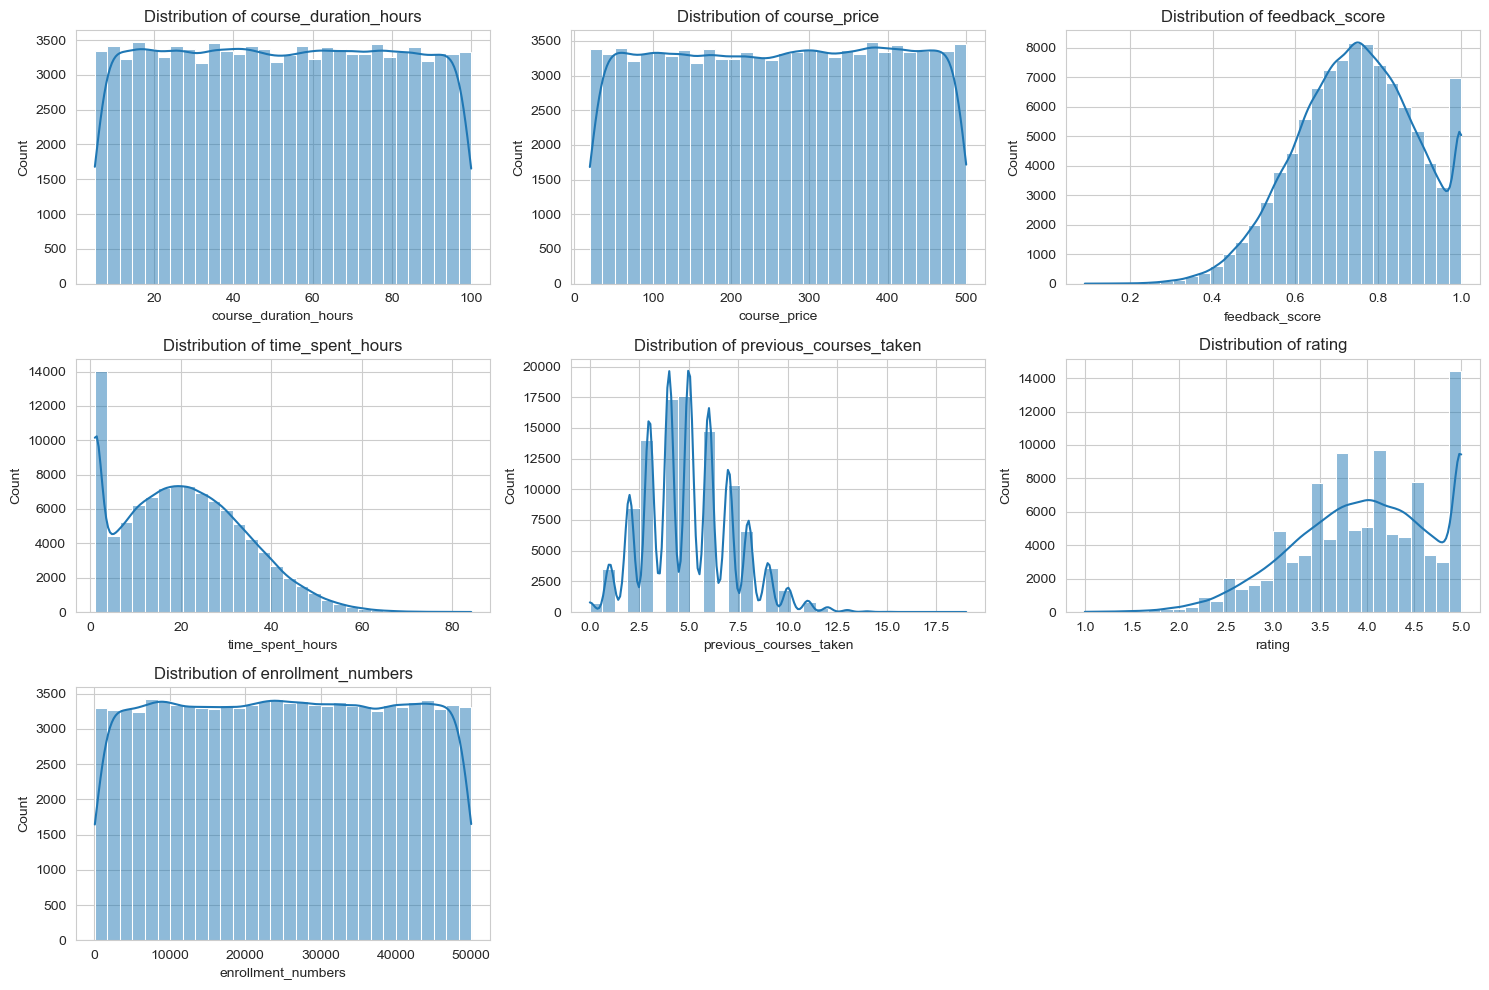

In [4]:
# Set style for plots
sns.set_style("whitegrid")

# Distribution of numerical features
num_cols = ['course_duration_hours', 'course_price', 'feedback_score',
            'time_spent_hours', 'previous_courses_taken', 'rating',
            'enrollment_numbers']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

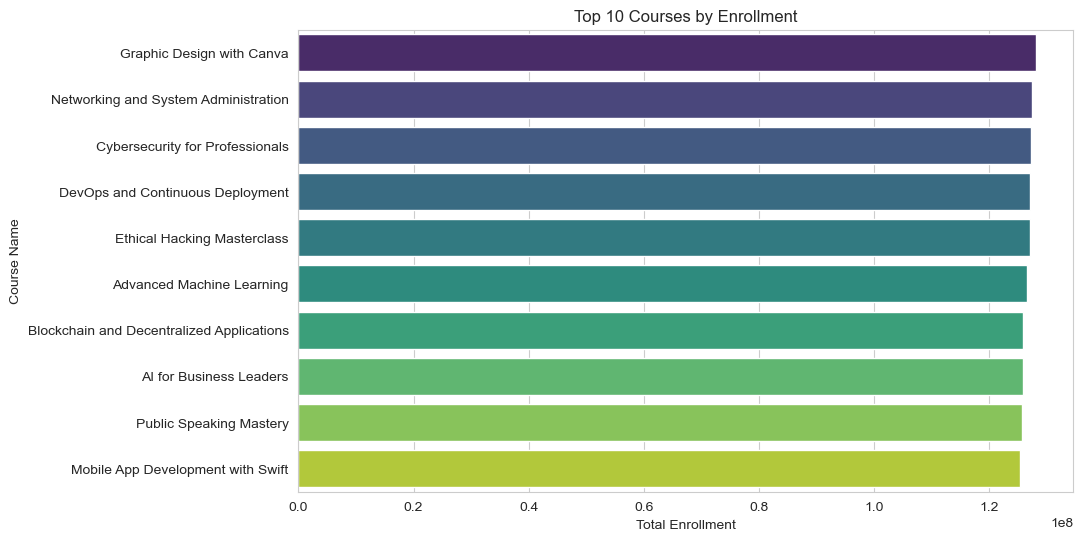

In [5]:
# Top courses by enrollment
top_courses = df.groupby('course_name')['enrollment_numbers'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_courses.values, y=top_courses.index, palette='viridis')
plt.title('Top 10 Courses by Enrollment')
plt.xlabel('Total Enrollment')
plt.ylabel('Course Name')
plt.show()

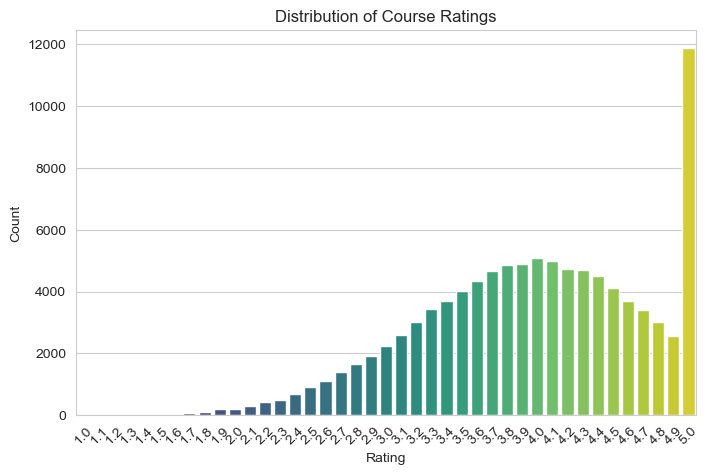

In [6]:
# Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df , palette='viridis')
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

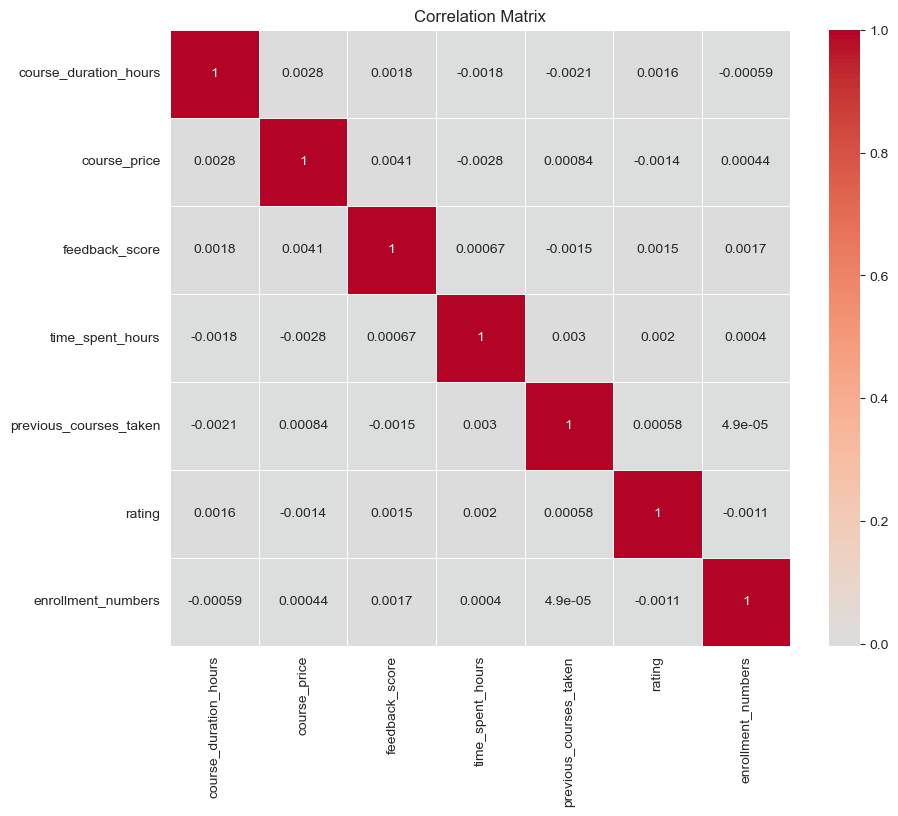

In [7]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0 , linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

## Feature Engineering

In [8]:
def engineer_features(df):
    """Create new features for recommendation"""
    print("\nPerforming feature engineering...")

    # 1. Create engagement score
    df['engagement_score'] = (df['time_spent_hours'] / df['course_duration_hours']) * df['rating']

    # 2. Create popularity score
    max_enrollment = df['enrollment_numbers'].max()
    df['popularity_score'] = df['enrollment_numbers'] / max_enrollment

    # 3. Create value for money metric
    df['value_for_money'] = df['rating'] / (df['course_price'] + 0.01)

    # 4. Instructor popularity
    instructor_stats = df.groupby('instructor').agg({
        'rating': 'mean',
        'enrollment_numbers': 'sum'
    }).reset_index()
    instructor_stats.columns = ['instructor', 'instructor_avg_rating', 'instructor_total_enrollment']

    df = pd.merge(df, instructor_stats, on='instructor', how='left')

    print("New features created:")
    print("- engagement_score")
    print("- popularity_score")
    print("- value_for_money")
    print("- instructor_avg_rating")
    print("- instructor_total_enrollment")

    return df

df = engineer_features(df)


Performing feature engineering...
New features created:
- engagement_score
- popularity_score
- value_for_money
- instructor_avg_rating
- instructor_total_enrollment


In [9]:
df

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken,engagement_score,popularity_score,value_for_money,instructor_avg_rating,instructor_total_enrollment
0,15796,9366,Python for Beginners,Emma Harris,39.099998,1,0,5.0,21600,317.500000,0.797,1,17.600000,4,2.250639,0.432009,0.015748,3.948371,127227072
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.299999,1,0,4.3,15379,40.990002,0.770,1,28.969999,9,3.431708,0.307586,0.104878,3.970305,122930224
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.400000,1,0,3.9,6431,380.809998,0.772,1,52.439999,4,15.262388,0.128623,0.010241,3.972397,124780998
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.299999,1,0,3.1,48245,342.799988,0.969,0,22.290001,6,1.185232,0.964919,0.009043,3.967267,121860396
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.799999,1,0,2.8,34556,381.010010,0.555,1,22.010000,5,2.000909,0.691134,0.007349,3.956177,123623242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10647,5466,Graphic Design with Canva,Emma Harris,17.299999,1,0,3.9,49101,485.339996,0.838,1,16.350000,3,3.685838,0.982040,0.008035,3.948371,127227072
99996,13800,2623,Stock Market and Trading Strategies,Dr. John Smith,68.400002,1,0,3.5,35107,162.800003,0.922,1,41.939999,7,2.146053,0.702154,0.021497,3.956280,125508783
99997,47131,1556,Networking and System Administration,Dr. John Smith,73.800003,1,0,4.3,12146,24.020000,0.990,1,15.870000,5,0.924675,0.242925,0.178943,3.956280,125508783
99998,49654,6001,Graphic Design with Canva,Daniel White,30.299999,1,0,3.5,9933,402.239990,0.630,1,21.049999,4,2.431518,0.198664,0.008701,3.956177,123623242


In [10]:
def prepare_model_data(df):
    """Prepare data for recommendation models"""
    print("\nPreparing data for modeling...")

    # For content-based filtering
    course_features = df[['course_id', 'course_duration_hours', 'difficulty_level',
                         'certification_offered', 'study_material_available',
                         'engagement_score', 'popularity_score', 'value_for_money'
                         ]].copy()

    # Drop duplicates (one row per course)
    course_features = course_features.drop_duplicates(subset=['course_id'])

    # Clean data for course features
    course_features = clean_data(course_features.copy())

    # For collaborative filtering
    user_item_matrix = df.pivot_table(index='user_id', columns='course_id', values='rating', fill_value=0)

    # Convert to sparse matrix for memory efficiency
    sparse_user_item = csr_matrix(user_item_matrix.values)

    print(f"Course features shape: {course_features.shape}")
    print(f"User-item matrix shape: {user_item_matrix.shape}")

    return course_features, user_item_matrix, sparse_user_item

course_features, user_item_matrix, sparse_user_item = prepare_model_data(df)


Preparing data for modeling...

Cleaning and preprocessing data...
Removed 0 duplicate rows

Data types after cleaning:
course_id                     int32
course_duration_hours       float32
difficulty_level            float64
certification_offered       float64
study_material_available    float64
engagement_score            float32
popularity_score            float64
value_for_money             float32
dtype: object
Course features shape: (9998, 8)
User-item matrix shape: (43242, 9998)


# Model Buliding 

## 1.Content-Based Filtering Models

In [11]:
def build_content_based_model(course_features):
    """Build content-based recommendation model"""
    print("\nBuilding Content-Based Filtering Model...")

    # Handle potential NaN values by filling with 0
    course_features_filled = course_features.fillna(0)

    # Standardize features
    scaler = StandardScaler()
    course_features_std = course_features_filled.drop('course_id', axis=1)
    course_features_std = pd.DataFrame(scaler.fit_transform(course_features_std),
                                     columns=course_features_std.columns)

    # Compute cosine similarity between courses
    cosine_sim = cosine_similarity(course_features_std)

    # Create course similarity matrix
    course_sim_df = pd.DataFrame(cosine_sim,
                                index=course_features_filled['course_id'],
                                columns=course_features_filled['course_id'])

    print("Content-based model built successfully!")
    return course_sim_df

course_sim_df = build_content_based_model(course_features)


Building Content-Based Filtering Model...
Content-based model built successfully!


## 2.Collaborative Filtering Model

In [12]:
def build_collaborative_model(df, sample_size=100000):
    """Build collaborative filtering model with a sample"""
    print("\nBuilding Collaborative Filtering Model...")

    # Create a sample of the data for Surprise
    sample_size = min(sample_size, len(df))
    df_sample = df.sample(sample_size, random_state=42)

    # Simple item-based CF using cosine similarity
    user_item = df_sample.pivot_table(index='user_id', columns='course_id', values='rating', fill_value=0)
    
    item_sim = cosine_similarity(user_item.T)
    item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

    print("Collaborative model built with cosine similarity!")
    return item_sim_df

knn_model = build_collaborative_model(df)


Building Collaborative Filtering Model...
Collaborative model built with cosine similarity!


### Recommendation System Functions

In [13]:
def content_based_recommendations(course_id, course_sim_df, df, n=5):
    """Get content-based recommendations for a course"""
    # Get similarity scores for the course
    sim_scores = course_sim_df[course_id]

    # Sort courses by similarity
    sim_scores = sim_scores.sort_values(ascending=False)

    # Get top n most similar courses (excluding itself)
    top_courses = sim_scores.iloc[1:n+1].index

    # Get course details
    recommendations = df[df['course_id'].isin(top_courses)][
        ['course_id', 'course_name', 'instructor', 'difficulty_level', 'rating']
    ].drop_duplicates()

    return recommendations

def collaborative_recommendations(course_id, item_sim_df, df, n=5):
    """Get collaborative filtering recommendations for a course"""
    if course_id not in item_sim_df.columns:
        return pd.DataFrame()
    
    sim_scores = item_sim_df[course_id].sort_values(ascending=False)
    top_courses = sim_scores.iloc[1:n+1].index
    
    recommendations = df[df['course_id'].isin(top_courses)][
        ['course_id', 'course_name', 'instructor', 'difficulty_level', 'rating']
    ].drop_duplicates()
    
    return recommendations

def get_popular_courses(df, n=5):
    """Get top n popular courses based on enrollment and rating"""
    popular = df.groupby(['course_id', 'course_name', 'instructor']).agg({
        'enrollment_numbers': 'sum',
        'rating': 'mean'
    }).reset_index()

    popular = popular.sort_values(['enrollment_numbers', 'rating'], ascending=False)
    return popular.head(n)[['course_id', 'course_name', 'instructor', 'rating']]

def hybrid_recommendations(user_id, course_sim_df, df, user_item_matrix, n=5):
    """Generate hybrid recommendations"""
    # 1. Get user's previously rated courses
    user_ratings = user_item_matrix.loc[user_id]
    rated_courses = user_ratings[user_ratings > 0].index.tolist()

    # If no ratings, return popular courses
    if not rated_courses:
        return get_popular_courses(df, n)

    # 2. Content-based: Get similar courses to what user has liked
    content_recs = []
    for course in rated_courses:
        if course in course_sim_df.columns:
            similar = content_based_recommendations(course, course_sim_df, df, n)
            content_recs.append(similar)

    if content_recs:
        content_recs = pd.concat(content_recs)
        content_recs = content_recs.sort_values('rating', ascending=False).head(n)

    return content_recs if not content_recs.empty else get_popular_courses(df, n)

print("Recommendation functions defined!")

Recommendation functions defined!


In [14]:
# # Content-based recommendations for a random course
# example_course = df['course_id'].sample(1).values[0]
# course_name = df[df['course_id'] == example_course]['course_name'].iloc[0]
# print(f"\nContent-based recommendations for course: {course_name} (ID: {example_course})")
# content_recs = content_based_recommendations(example_course, course_sim_df, df)
# content_recs

In [15]:
# # Hybrid recommendations for a random user
# example_user = df['user_id'].sample(1).values[0]
# print(f"\nHybrid recommendations for user ID: {example_user}")
# hybrid_recs = hybrid_recommendations(example_user, course_sim_df, knn_model, df, user_item_matrix)
# hybrid_recs

In [16]:
# # Show popular courses
# print("\nTop 5 Popular Courses Overall:")
# get_popular_courses(df)

### Model 1: Content-Based Filtering
Recommends courses based on course features (duration, price, difficulty, ratings, etc.)


In [17]:
# Content-Based Model Example
print("\n" + "="*70)
print("MODEL 1: CONTENT-BASED FILTERING")
print("="*70)
print("\nHow it works: Finds courses similar to ones the user has rated high")
print("Based on features: duration, price, difficulty, ratings, engagement, etc.\n")

# Example: Get recommendations for a specific course
example_course = df['course_id'].sample(1).values[0]
course_name = df[df['course_id'] == example_course]['course_name'].iloc[0]
print(f"Finding courses similar to: '{course_name}' (Course ID: {example_course})\n")

content_recs = content_based_recommendations(example_course, course_sim_df, df, n=5)
print(f"Top 5 Similar Courses:")
content_recs.head()



MODEL 1: CONTENT-BASED FILTERING

How it works: Finds courses similar to ones the user has rated high
Based on features: duration, price, difficulty, ratings, engagement, etc.

Finding courses similar to: 'Fitness and Nutrition Coaching' (Course ID: 4150)

Top 5 Similar Courses:


,course_id,course_name,instructor,difficulty_level,rating
3951,9154,AI for Business Leaders,Isabella Scott,1,4.4
5105,5834,Stock Market and Trading Strategies,Liam Adams,0,3.4
6539,8913,Networking and System Administration,Ethan Hall,0,5.0
6704,9154,Cybersecurity for Professionals,Dr. Mia Walker,1,4.1
8325,464,Cloud Computing Essentials,James Clark,0,4.1


### Model 2: Collaborative Filtering
Recommends courses based on similar users' preferences and ratings


In [18]:
# Collaborative Filtering Model Example
print("\n" + "="*70)
print("MODEL 2: COLLABORATIVE FILTERING")
print("="*70)
print("\nHow it works: 'Users who liked X also liked Y'")
print("Uses item-item similarity from rating patterns\n")

# Example: Get collaborative recommendations for a course
print(f"Users who rated '{course_name}' also rated these courses:\n")
collab_recs = collaborative_recommendations(example_course, knn_model, df, n=5)
if not collab_recs.empty:
    print(f"Top 5 Collaborative Recommendations:")
    print(collab_recs.head().to_string())
else:
    print("No recommendations available for this course")


MODEL 2: COLLABORATIVE FILTERING

How it works: 'Users who liked X also liked Y'
Uses item-item similarity from rating patterns

Users who rated 'Fitness and Nutrition Coaching' also rated these courses:

Top 5 Collaborative Recommendations:
       course_id                           course_name       instructor  difficulty_level  rating
14328       2026         Photography and Video Editing   Isabella Scott                 1     4.4
15596       2026               Public Speaking Mastery   William Thomas                 0     3.7
18185       5145      DevOps and Continuous Deployment  Sophia Anderson                 1     3.7
18401       1834         Photography and Video Editing      Emma Harris                 0     3.8
19811       4375  Personal Finance and Wealth Building    Michael Brown                 0     3.8


### Model 3: Hybrid Recommendations
Combines content-based and collaborative filtering for better results


In [19]:
# Hybrid Model Example
print("\n" + "="*70)
print("MODEL 3: HYBRID RECOMMENDATIONS")
print("="*70)
print("\nHow it works: Combines content-based + collaborative filtering")
print("Takes user's rated courses and finds similar courses\n")

# Example: Get hybrid recommendations for a user
example_user = df['user_id'].sample(1).values[0]
print(f"Getting personalized recommendations for User ID: {example_user}\n")

hybrid_recs = hybrid_recommendations(example_user, course_sim_df, df, user_item_matrix, n=5)
print(f"Top 5 Hybrid Recommendations:")
hybrid_recs


MODEL 3: HYBRID RECOMMENDATIONS

How it works: Combines content-based + collaborative filtering
Takes user's rated courses and finds similar courses

Getting personalized recommendations for User ID: 30444

Top 5 Hybrid Recommendations:


,course_id,course_name,instructor,difficulty_level,rating
5738,2076,Fundamentals of Digital Marketing,Dr. Mia Walker,2,5.0
28932,795,Data Visualization with Tableau,Sophia Anderson,1,5.0
19166,4643,DevOps and Continuous Deployment,Isabella Scott,0,5.0
51001,2076,Public Speaking Mastery,William Thomas,1,5.0
45470,5179,Stock Market and Trading Strategies,Ethan Hall,2,5.0


### Model 4: Popular Courses
Recommends trending/popular courses based on enrollment and ratings (cold-start solution)


In [20]:
# Popular Courses Model Example
print("\n" + "="*70)
print("MODEL 4: POPULAR COURSES")
print("="*70)
print("\nHow it works: Recommends trending courses by enrollment + rating")
print("Best for new users (cold-start problem) or discovery\n")

popular_recs = get_popular_courses(df, n=5)
print(f"Top 5 Most Popular Courses:")
print(pd.DataFrame(popular_recs).to_string())


MODEL 4: POPULAR COURSES

How it works: Recommends trending courses by enrollment + rating
Best for new users (cold-start problem) or discovery

Top 5 Most Popular Courses:
       course_id                          course_name      instructor    rating
45859       4659  Stock Market and Trading Strategies  Dr. Mia Walker  3.733334
7238         733                 Python for Beginners  Dr. John Smith  4.766667
84317       8541            Advanced Machine Learning  Isabella Scott  3.866667
80300       8129    Fundamentals of Digital Marketing     Emma Harris  3.500000
94391       9562      Cybersecurity for Professionals  William Thomas  4.050000


### Deployment using Streamlit 

In [21]:
import pickle

# Save models
with open('course_sim.pkl', 'wb') as f:
    pickle.dump(course_sim_df, f)

with open('item_sim.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

with open('user_item.pkl', 'wb') as f:
    pickle.dump(user_item_matrix, f)

with open('data.pkl', 'wb') as f:
    pickle.dump(df, f)

print("Models saved successfully!")

Models saved successfully!
